<a href="https://colab.research.google.com/github/ShoaibAkhtar433/ML-Task1/blob/main/Prediction_of_Future_Stock_Prices__Task2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Importing Libraries
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
# Fetching Dataset using yfinance library
stock = yf.download("GOOGL", start="2023-01-01", end="2026-01-01")
stock

/tmp/ipykernel_4479/4044693588.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock = yf.download("GOOGL", start="2023-01-01", end="2026-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,GOOGL,GOOGL,GOOGL,GOOGL,GOOGL
Date,,,,,
2023-01-03,88.389465,90.303645,87.794378,88.855606,28131200
2023-01-04,87.357979,89.906911,86.554614,89.609367,34854800
2023-01-05,85.493393,86.852165,85.195857,86.752987,27194400
2023-01-06,86.624054,86.971191,84.164387,86.078567,41381500
2023-01-09,87.298470,89.311835,87.139785,87.635686,29003900
...,...,...,...,...,...
2025-12-24,313.869049,314.858343,311.700593,314.548563,10097400
2025-12-26,313.289459,314.868334,312.060314,314.258778,10899000


In [4]:
#  Adding Prediction Column
stock['Next_Close'] = stock['Close'].shift(-1)
stock

Price,Close,High,Low,Open,Volume,Next_Close
Ticker,GOOGL,GOOGL,GOOGL,GOOGL,GOOGL,
Date,,,,,,
2023-01-03,88.389465,90.303645,87.794378,88.855606,28131200,87.357979
2023-01-04,87.357979,89.906911,86.554614,89.609367,34854800,85.493393
2023-01-05,85.493393,86.852165,85.195857,86.752987,27194400,86.624054
2023-01-06,86.624054,86.971191,84.164387,86.078567,41381500,87.298470
2023-01-09,87.298470,89.311835,87.139785,87.635686,29003900,87.695206
...,...,...,...,...,...,...
2025-12-24,313.869049,314.858343,311.700593,314.548563,10097400,313.289459
2025-12-26,313.289459,314.868334,312.060314,314.258778,10899000,313.339417


In [5]:
# Drop Last Row (It has no next  value)
stock = stock.iloc[:-1]
stock

Price,Close,High,Low,Open,Volume,Next_Close
Ticker,GOOGL,GOOGL,GOOGL,GOOGL,GOOGL,
Date,,,,,,
2023-01-03,88.389465,90.303645,87.794378,88.855606,28131200,87.357979
2023-01-04,87.357979,89.906911,86.554614,89.609367,34854800,85.493393
2023-01-05,85.493393,86.852165,85.195857,86.752987,27194400,86.624054
2023-01-06,86.624054,86.971191,84.164387,86.078567,41381500,87.298470
2023-01-09,87.298470,89.311835,87.139785,87.635686,29003900,87.695206
...,...,...,...,...,...,...
2025-12-23,314.128876,314.718457,309.102415,309.412195,25478700,313.869049
2025-12-24,313.869049,314.858343,311.700593,314.548563,10097400,313.289459


In [6]:
# Features (inputs)
X = stock[['Open', 'High', 'Low', 'Volume']]
X


Price,Open,High,Low,Volume
Ticker,GOOGL,GOOGL,GOOGL,GOOGL
Date,,,,
2023-01-03,88.855606,90.303645,87.794378,28131200
2023-01-04,89.609367,89.906911,86.554614,34854800
2023-01-05,86.752987,86.852165,85.195857,27194400
2023-01-06,86.078567,86.971191,84.164387,41381500
2023-01-09,87.635686,89.311835,87.139785,29003900
...,...,...,...,...
2025-12-23,309.412195,314.718457,309.102415,25478700
2025-12-24,314.548563,314.858343,311.700593,10097400


In [8]:
# Target (output)
Y = stock['Next_Close']
Y

,Next_Close
Date,
2023-01-03,87.357979
2023-01-04,85.493393
2023-01-05,86.624054
2023-01-06,87.298470
2023-01-09,87.695206
...,...
2025-12-23,313.869049
2025-12-24,313.289459
2025-12-26,313.339417


In [9]:
# Splitting Data into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [12]:
# Implementing Linear Regression Model
model = LinearRegression()
model.fit(X_train, Y_train)

LinearRegression()

In [13]:
# Predicted Stock Prices
Y_pred = model.predict(X_test)
Y_pred

array([176.09975946, 174.22009146, 124.53597875, 136.71313002,
       139.37191871, 278.67533159, 165.93259724, 128.20571513,
       183.05326286, 319.6549066 , 122.33787532, 149.68035487,
       140.75675983, 314.04275873, 128.00875831, 150.62563685,
        89.69791251, 139.73952574, 177.29992412, 169.8045447 ,
       313.73707336, 190.55417433, 149.00901885, 157.37390415,
       105.21296571, 284.72797691, 139.30837889, 157.60066383,
       133.72916141, 134.95363685, 174.86859268, 286.94155254,
       164.03854636, 169.08218047, 178.75842737, 103.67984449,
       126.88807622, 160.96863142, 106.75333071, 321.58303697,
       104.39712654, 171.59918233,  91.49269868, 116.92918992,
       158.94528324, 159.18517638, 192.45496186, 195.65684928,
       170.79213218, 158.08882769,  90.71345096, 189.41011999,
       178.75721851, 154.84018831, 180.64338578, 122.06879959,
       174.86142498, 104.77272941, 321.68324389, 104.39557501,
       136.97187111, 126.04691238, 290.80000361, 273.21

In [18]:
# Converting Predicted Prices from Array Form to DataFrame Column
Y_pred_df = pd.DataFrame(Y_pred, columns=['Predicted_Next_Close'])
display(Y_pred_df)

,Predicted_Next_Close
0,176.099759
1,174.220091
2,124.535979
3,136.713130
4,139.371919
...,...
146,116.498270
147,168.756258
148,283.405313
149,106.021029


In [14]:
# Evaluation of Model
mse = mean_squared_error(Y_test, Y_pred)
print("Mean Squared Error: ", mse)

Mean Squared Error:  11.883452601122311


<function matplotlib.pyplot.show(close=None, block=None)>

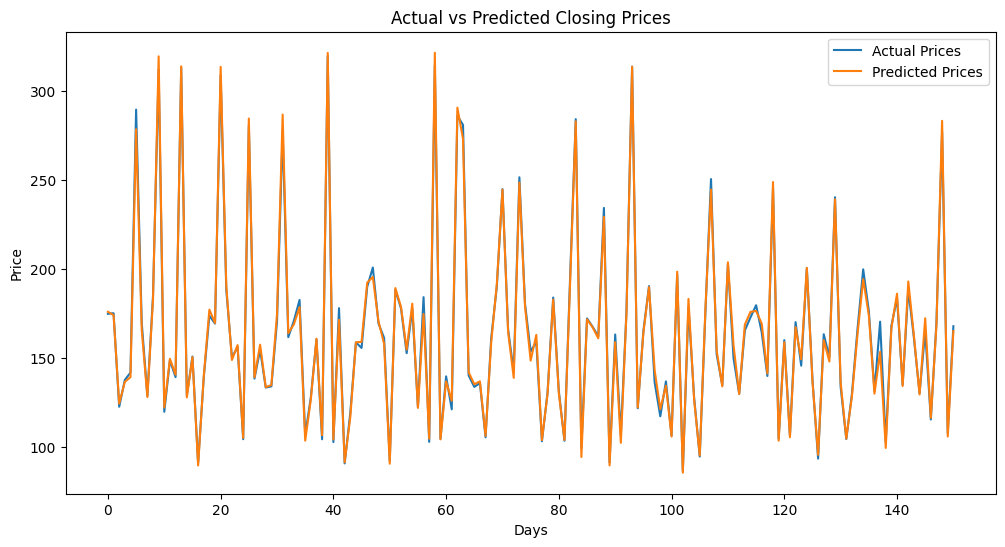

In [15]:
# Putting Sizes to Diagram
plt.figure(figsize=(12, 6))

# Labeling Actual Prices to Y_test Values
plt.plot(Y_test.values, label='Actual Prices')

# Labeling Predited Prices to Y_pred Values
plt.plot(Y_pred, label='Predicted Prices')

# Generating a Box Showing Different Colors for Actual & Predicted Prices
plt.legend()

# Giving Title to the Diagram
plt.title("Actual vs Predicted Closing Prices")

# Showing x-asis 'Days' & y-axis 'Prices'
plt.xlabel('Days')
plt.ylabel('Price')

# Displaying tthe Final Graph
plt.show